In [1]:
import pandas as pd

# Load the raw UPI transaction dataset
file_path = "../data/raw/upi_transaction_insights_dataset.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,transaction_id,date,time,amount,merchant_category,payment_mode,location_type,is_successful
0,TXN100000,2024-09-13,22:02,1399.65,Fuel,QR,Rural,No
1,TXN100001,2024-12-06,11:00,3250.00,Groceries,QR,Urban,Yes
2,TXN100002,2024-05-12,14:53,241.22,Online Services,Contact,Rural,No
3,TXN100003,2024-02-17,22:22,3268.35,Food & Dining,Online,Semi-Urban,Yes
4,TXN100004,2024-06-18,00:11,879.46,Groceries,Contact,Rural,No


In [2]:
# Check the structure of the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (500, 8)

Column Names:
['transaction_id', 'date', 'time', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful']

Data Types:
transaction_id        object
date                  object
time                  object
amount               float64
merchant_category     object
payment_mode          object
location_type         object
is_successful         object
dtype: object


In [3]:
# Check for missing values and duplicate records

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSuccessful vs Failed Transactions:")
print(df["is_successful"].value_counts())

Missing Values:
transaction_id       0
date                 0
time                 0
amount               0
merchant_category    0
payment_mode         0
location_type        0
is_successful        0
dtype: int64

Duplicate Rows:
0

Successful vs Failed Transactions:
is_successful
No     250
Yes    250
Name: count, dtype: int64


In [4]:
# Check unique values in categorical columns

categorical_columns = [
    "merchant_category",
    "payment_mode",
    "location_type",
    "is_successful"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


merchant_category:
merchant_category
Online Services      60
Health & Pharmacy    54
Fuel                 53
Groceries            52
Food & Dining        50
Travel               50
Shopping             47
Entertainment        46
Other                44
Bills & Utilities    44
Name: count, dtype: int64

payment_mode:
payment_mode
Online     134
QR         128
Contact    120
AutoPay    118
Name: count, dtype: int64

location_type:
location_type
Urban         174
Rural         173
Semi-Urban    153
Name: count, dtype: int64

is_successful:
is_successful
No     250
Yes    250
Name: count, dtype: int64


In [5]:
# Analyze transaction amounts

print("Amount Statistics:")
print(df["amount"].describe())

Amount Statistics:
count     500.000000
mean     2523.668540
std      1472.660245
min        17.620000
25%      1277.352500
50%      2552.815000
75%      3802.867500
max      4973.820000
Name: amount, dtype: float64


In [6]:
# Analyze transaction dates and times

print("Date Range:")
print("Earliest Date:", df["date"].min())
print("Latest Date:", df["date"].max())

print("\nUnique Dates:", df["date"].nunique())
print("Unique Times:", df["time"].nunique())

Date Range:
Earliest Date: 2024-01-01
Latest Date: 2024-12-30

Unique Dates: 265
Unique Times: 422


In [7]:
# Check transaction ID uniqueness

print("Total Transactions:", len(df))
print("Unique Transaction IDs:", df["transaction_id"].nunique())

print("\nDuplicate Transaction IDs:")
print(df["transaction_id"].duplicated().sum())

Total Transactions: 500
Unique Transaction IDs: 500

Duplicate Transaction IDs:
0


In [8]:
# Analyze failed transactions

failed_df = df[df["is_successful"] == "No"]

print("Total Failed Transactions:", len(failed_df))

print("\nFailed Transaction Amount Statistics:")
print(failed_df["amount"].describe())

print("\nTotal Potential Failed Transaction Value:")
print(failed_df["amount"].sum())

Total Failed Transactions: 250

Failed Transaction Amount Statistics:
count     250.000000
mean     2496.011160
std      1473.458983
min        23.750000
25%      1272.402500
50%      2403.755000
75%      3778.435000
max      4963.920000
Name: amount, dtype: float64

Total Potential Failed Transaction Value:
624002.79


In [9]:
# Analyze payment success and failure by payment mode

payment_mode_analysis = pd.crosstab(
    df["payment_mode"],
    df["is_successful"],
    normalize="index"
) * 100

print("Success and Failure Rate by Payment Mode:")
print(payment_mode_analysis)

Success and Failure Rate by Payment Mode:
is_successful         No        Yes
payment_mode                       
AutoPay        44.915254  55.084746
Contact        55.833333  44.166667
Online         49.253731  50.746269
QR             50.000000  50.000000


In [10]:
# Analyze payment success and failure by merchant category

merchant_category_analysis = pd.crosstab(
    df["merchant_category"],
    df["is_successful"],
    normalize="index"
) * 100

print("Success and Failure Rate by Merchant Category:")
print(merchant_category_analysis.sort_values("No", ascending=False))

Success and Failure Rate by Merchant Category:
is_successful             No        Yes
merchant_category                      
Food & Dining      60.000000  40.000000
Other              56.818182  43.181818
Entertainment      56.521739  43.478261
Online Services    53.333333  46.666667
Travel             50.000000  50.000000
Groceries          48.076923  51.923077
Shopping           46.808511  53.191489
Bills & Utilities  45.454545  54.545455
Health & Pharmacy  44.444444  55.555556
Fuel               39.622642  60.377358


In [11]:
# Analyze payment success and failure by location type

location_analysis = pd.crosstab(
    df["location_type"],
    df["is_successful"],
    normalize="index"
) * 100

print("Success and Failure Rate by Location:")
print(location_analysis.sort_values("No", ascending=False))

Success and Failure Rate by Location:
is_successful         No        Yes
location_type                      
Rural          54.335260  45.664740
Urban          49.425287  50.574713
Semi-Urban     45.751634  54.248366


In [12]:
# Compare transaction amounts between successful and failed payments

amount_by_status = df.groupby("is_successful")["amount"].agg(
    ["count", "mean", "median", "sum", "min", "max"]
)

print("Transaction Amount Analysis by Payment Status:")
print(amount_by_status)

Transaction Amount Analysis by Payment Status:
               count        mean    median        sum    min      max
is_successful                                                        
No               250  2496.01116  2403.755  624002.79  23.75  4963.92
Yes              250  2551.32592  2679.005  637831.48  17.62  4973.82


In [13]:
# Calculate key payment failure KPIs

total_transactions = len(df)
failed_transactions = (df["is_successful"] == "No").sum()

total_transaction_value = df["amount"].sum()
failed_transaction_value = df.loc[
    df["is_successful"] == "No", "amount"
].sum()

failure_rate = (failed_transactions / total_transactions) * 100
failed_value_percentage = (
    failed_transaction_value / total_transaction_value
) * 100

print("Payment Failure KPIs")
print("--------------------")
print(f"Total Transactions: {total_transactions}")
print(f"Failed Transactions: {failed_transactions}")
print(f"Failure Rate: {failure_rate:.2f}%")
print(f"Total Transaction Value: ₹{total_transaction_value:,.2f}")
print(f"Failed Transaction Value: ₹{failed_transaction_value:,.2f}")
print(f"Failed Value Percentage: {failed_value_percentage:.2f}%")

Payment Failure KPIs
--------------------
Total Transactions: 500
Failed Transactions: 250
Failure Rate: 50.00%
Total Transaction Value: ₹1,261,834.27
Failed Transaction Value: ₹624,002.79
Failed Value Percentage: 49.45%


In [14]:
# Combine date and time into a single timestamp 

df["timestamp"] = pd.to_datetime(
    df["date"] + " " + df["time"]
)

print("Timestamp Data Type:")
print(df["timestamp"].dtype)

print("\nEarliest Timestamp:")
print(df["timestamp"].min())

print("\nLatest Timestamp:")
print(df["timestamp"].max())

print("\nFirst 5 Timestamps:")
print(df["timestamp"].head())

Timestamp Data Type:
datetime64[ns]

Earliest Timestamp:
2024-01-01 14:48:00

Latest Timestamp:
2024-12-30 06:40:00

First 5 Timestamps:
0   2024-09-13 22:02:00
1   2024-12-06 11:00:00
2   2024-05-12 14:53:00
3   2024-02-17 22:22:00
4   2024-06-18 00:11:00
Name: timestamp, dtype: datetime64[ns]


In [15]:
# Sort transactions chronologically and calculate time gaps

df_sorted = df.sort_values("timestamp").copy()

df_sorted["time_gap"] = df_sorted["timestamp"].diff()

print("First 10 chronological transactions:")
print(
    df_sorted[
        ["transaction_id", "timestamp", "amount", "is_successful", "time_gap"]
    ].head(10)
)

print("\nTime Gap Statistics:")
print(df_sorted["time_gap"].describe())

First 10 chronological transactions:
    transaction_id           timestamp   amount is_successful        time_gap
148      TXN100148 2024-01-01 14:48:00  4571.70           Yes             NaT
22       TXN100022 2024-01-01 16:12:00  4505.80            No 0 days 01:24:00
123      TXN100123 2024-01-01 17:29:00  4651.69            No 0 days 01:17:00
227      TXN100227 2024-01-01 22:09:00   975.80            No 0 days 04:40:00
418      TXN100418 2024-01-02 06:32:00   879.71            No 0 days 08:23:00
411      TXN100411 2024-01-02 16:38:00  2538.96           Yes 0 days 10:06:00
339      TXN100339 2024-01-03 04:49:00  2144.37           Yes 0 days 12:11:00
125      TXN100125 2024-01-03 18:39:00   512.00            No 0 days 13:50:00
395      TXN100395 2024-01-03 19:40:00  4767.10            No 0 days 01:01:00
179      TXN100179 2024-01-04 06:07:00  1697.81           Yes 0 days 10:27:00

Time Gap Statistics:
count                          499
mean     0 days 17:29:26.573146292
std      0 da

In [16]:
# Inspect transaction ID patterns

print("First 10 Transaction IDs:")
print(df["transaction_id"].head(10).tolist())

print("\nLast 10 Transaction IDs:")
print(df["transaction_id"].tail(10).tolist())

print("\nNumber of unique transaction IDs:")
print(df["transaction_id"].nunique())

print("\nNumber of unique IDs after removing 'TXN':")
print(df["transaction_id"].str.replace("TXN", "", regex=False).nunique())

First 10 Transaction IDs:
['TXN100000', 'TXN100001', 'TXN100002', 'TXN100003', 'TXN100004', 'TXN100005', 'TXN100006', 'TXN100007', 'TXN100008', 'TXN100009']

Last 10 Transaction IDs:
['TXN100490', 'TXN100491', 'TXN100492', 'TXN100493', 'TXN100494', 'TXN100495', 'TXN100496', 'TXN100497', 'TXN100498', 'TXN100499']

Number of unique transaction IDs:
500

Number of unique IDs after removing 'TXN':
500


In [17]:
# Check unique values and their counts for all categorical columns

for column in df.select_dtypes(include="object").columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- transaction_id ---
transaction_id
TXN100000    1
TXN100329    1
TXN100342    1
TXN100341    1
TXN100340    1
            ..
TXN100161    1
TXN100160    1
TXN100159    1
TXN100158    1
TXN100499    1
Name: count, Length: 500, dtype: int64

--- date ---
date
2024-06-07    5
2024-07-01    5
2024-09-08    5
2024-04-11    4
2024-07-05    4
             ..
2024-12-05    1
2024-09-06    1
2024-10-27    1
2024-09-16    1
2024-10-17    1
Name: count, Length: 265, dtype: int64

--- time ---
time
18:05    3
23:51    3
02:38    3
13:06    3
20:50    3
        ..
12:37    1
01:13    1
18:02    1
15:35    1
20:11    1
Name: count, Length: 422, dtype: int64

--- merchant_category ---
merchant_category
Online Services      60
Health & Pharmacy    54
Fuel                 53
Groceries            52
Food & Dining        50
Travel               50
Shopping             47
Entertainment        46
Other                44
Bills & Utilities    44
Name: count, dtype: int64

--- payment_mode ---
payment_mod

In [18]:
# Create a separate working copy of the raw dataset

clean_df = df.copy()

# Convert date and time into a proper timestamp
clean_df["timestamp"] = pd.to_datetime(
    clean_df["date"] + " " + clean_df["time"]
)

# Sort transactions chronologically
clean_df = clean_df.sort_values("timestamp").reset_index(drop=True)

print("Cleaned Dataset Shape:", clean_df.shape)

print("\nColumns:")
print(clean_df.columns.tolist())

print("\nFirst 5 rows:")
print(clean_df.head())

Cleaned Dataset Shape: (500, 9)

Columns:
['transaction_id', 'date', 'time', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'timestamp']

First 5 rows:
  transaction_id        date   time   amount merchant_category payment_mode  \
0      TXN100148  2024-01-01  14:48  4571.70   Online Services       Online   
1      TXN100022  2024-01-01  16:12  4505.80          Shopping       Online   
2      TXN100123  2024-01-01  17:29  4651.69     Food & Dining       Online   
3      TXN100227  2024-01-01  22:09   975.80          Shopping           QR   
4      TXN100418  2024-01-02  06:32   879.71   Online Services       Online   

  location_type is_successful           timestamp  
0         Rural           Yes 2024-01-01 14:48:00  
1    Semi-Urban            No 2024-01-01 16:12:00  
2    Semi-Urban            No 2024-01-01 17:29:00  
3         Urban            No 2024-01-01 22:09:00  
4         Urban            No 2024-01-02 06:32:00  


In [19]:
# Create time-based features from the transaction timestamp

clean_df["transaction_date"] = clean_df["timestamp"].dt.date
clean_df["transaction_hour"] = clean_df["timestamp"].dt.hour
clean_df["day_of_week"] = clean_df["timestamp"].dt.day_name()

print("Time-based features created successfully.")

print("\nSample:")
print(
    clean_df[
        ["timestamp", "transaction_date", "transaction_hour", "day_of_week"]
    ].head()
)

Time-based features created successfully.

Sample:
            timestamp transaction_date  transaction_hour day_of_week
0 2024-01-01 14:48:00       2024-01-01                14      Monday
1 2024-01-01 16:12:00       2024-01-01                16      Monday
2 2024-01-01 17:29:00       2024-01-01                17      Monday
3 2024-01-01 22:09:00       2024-01-01                22      Monday
4 2024-01-02 06:32:00       2024-01-02                 6     Tuesday


In [20]:
# Analyze payment success and failure by transaction hour

hourly_analysis = pd.crosstab(
    clean_df["transaction_hour"],
    clean_df["is_successful"],
    normalize="index"
) * 100

print("Success and Failure Rate by Hour:")
print(hourly_analysis.sort_values("No", ascending=False))


Success and Failure Rate by Hour:
is_successful            No        Yes
transaction_hour                      
7                 72.222222  27.777778
10                68.750000  31.250000
9                 60.000000  40.000000
21                59.090909  40.909091
13                57.894737  42.105263
1                 57.894737  42.105263
15                56.000000  44.000000
12                53.571429  46.428571
19                52.631579  47.368421
0                 50.000000  50.000000
8                 50.000000  50.000000
4                 50.000000  50.000000
3                 50.000000  50.000000
2                 50.000000  50.000000
14                48.000000  52.000000
6                 45.454545  54.545455
23                45.454545  54.545455
20                44.444444  55.555556
11                43.333333  56.666667
22                42.857143  57.142857
17                42.307692  57.692308
16                42.105263  57.894737
18                41.666667  5

In [21]:
# Check transaction volume by hour

hourly_volume = (
    clean_df["transaction_hour"]
    .value_counts()
    .sort_index()
)

print("Transaction Volume by Hour:")
print(hourly_volume)

Transaction Volume by Hour:
transaction_hour
0     24
1     19
2     20
3     18
4     14
5     20
6     22
7     18
8     14
9     15
10    16
11    30
12    28
13    19
14    25
15    25
16    19
17    26
18    24
19    19
20    27
21    22
22    14
23    22
Name: count, dtype: int64


In [22]:
# Check transaction volume by hour

hourly_volume = (
    clean_df["transaction_hour"]
    .value_counts()
    .sort_index()
)

print("Transaction Volume by Hour:")
print(hourly_volume)

Transaction Volume by Hour:
transaction_hour
0     24
1     19
2     20
3     18
4     14
5     20
6     22
7     18
8     14
9     15
10    16
11    30
12    28
13    19
14    25
15    25
16    19
17    26
18    24
19    19
20    27
21    22
22    14
23    22
Name: count, dtype: int64


In [23]:
# Analyze payment success and failure by day of week

day_analysis = pd.crosstab(
    clean_df["day_of_week"],
    clean_df["is_successful"],
    normalize="index"
) * 100

print("Success and Failure Rate by Day of Week:")
print(day_analysis.sort_values("No", ascending=False))

Success and Failure Rate by Day of Week:
is_successful         No        Yes
day_of_week                        
Wednesday      58.064516  41.935484
Sunday         56.338028  43.661972
Monday         50.746269  49.253731
Thursday       48.648649  51.351351
Tuesday        46.250000  53.750000
Friday         46.052632  53.947368
Saturday       45.714286  54.285714


In [24]:
# Check the fields available for payment analysis

required_fields = {
    "Transaction ID": "transaction_id",
    "Transaction Date": "date",
    "Transaction Time": "time",
    "Transaction Amount": "amount",
    "Merchant Category": "merchant_category",
    "Payment Mode": "payment_mode",
    "Location Type": "location_type",
    "Payment Outcome": "is_successful",
    "Timestamp": "timestamp"
}

print("Available Payment Analysis Fields:")
print("----------------------------------")

for name, column in required_fields.items():
    print(f"{name}: {'Available' if column in clean_df.columns else 'Missing'}")

print("\nRetry Information:")
print("------------------")
retry_fields = [
    "retry_count",
    "attempt_number",
    "original_transaction_id",
    "customer_id"
]

for column in retry_fields:
    print(f"{column}: {'Available' if column in clean_df.columns else 'Missing'}")

print("\nBank Response Information:")
print("--------------------------")
response_fields = [
    "response_code",
    "bank_response_code"
]

for column in response_fields:
    print(f"{column}: {'Available' if column in clean_df.columns else 'Missing'}")

Available Payment Analysis Fields:
----------------------------------
Transaction ID: Available
Transaction Date: Available
Transaction Time: Available
Transaction Amount: Available
Merchant Category: Available
Payment Mode: Available
Location Type: Available
Payment Outcome: Available
Timestamp: Available

Retry Information:
------------------
retry_count: Missing
attempt_number: Missing
original_transaction_id: Missing
customer_id: Missing

Bank Response Information:
--------------------------
response_code: Missing
bank_response_code: Missing


In [25]:
# Create retry-analysis-ready dataset

retry_dataset = clean_df[
    [
        "transaction_id",
        "timestamp",
        "amount",
        "merchant_category",
        "payment_mode",
        "location_type",
        "is_successful",
        "transaction_hour",
        "day_of_week"
    ]
].copy()

print("Retry Dataset Shape:", retry_dataset.shape)

print("\nRetry Dataset Columns:")
print(retry_dataset.columns.tolist())

print("\nFirst 5 Rows:")
print(retry_dataset.head())

Retry Dataset Shape: (500, 9)

Retry Dataset Columns:
['transaction_id', 'timestamp', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'transaction_hour', 'day_of_week']

First 5 Rows:
  transaction_id           timestamp   amount merchant_category payment_mode  \
0      TXN100148 2024-01-01 14:48:00  4571.70   Online Services       Online   
1      TXN100022 2024-01-01 16:12:00  4505.80          Shopping       Online   
2      TXN100123 2024-01-01 17:29:00  4651.69     Food & Dining       Online   
3      TXN100227 2024-01-01 22:09:00   975.80          Shopping           QR   
4      TXN100418 2024-01-02 06:32:00   879.71   Online Services       Online   

  location_type is_successful  transaction_hour day_of_week  
0         Rural           Yes                14      Monday  
1    Semi-Urban            No                16      Monday  
2    Semi-Urban            No                17      Monday  
3         Urban            No                22      M

In [26]:
# Create response-code analysis-ready dataset

response_code_dataset = clean_df[
    [
        "transaction_id",
        "timestamp",
        "amount",
        "merchant_category",
        "payment_mode",
        "location_type",
        "is_successful",
        "transaction_hour",
        "day_of_week"
    ]
].copy()

print("Response Code Dataset Shape:", response_code_dataset.shape)

print("\nResponse Code Dataset Columns:")
print(response_code_dataset.columns.tolist())

print("\nFirst 5 Rows:")
print(response_code_dataset.head())

Response Code Dataset Shape: (500, 9)

Response Code Dataset Columns:
['transaction_id', 'timestamp', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'transaction_hour', 'day_of_week']

First 5 Rows:
  transaction_id           timestamp   amount merchant_category payment_mode  \
0      TXN100148 2024-01-01 14:48:00  4571.70   Online Services       Online   
1      TXN100022 2024-01-01 16:12:00  4505.80          Shopping       Online   
2      TXN100123 2024-01-01 17:29:00  4651.69     Food & Dining       Online   
3      TXN100227 2024-01-01 22:09:00   975.80          Shopping           QR   
4      TXN100418 2024-01-02 06:32:00   879.71   Online Services       Online   

  location_type is_successful  transaction_hour day_of_week  
0         Rural           Yes                14      Monday  
1    Semi-Urban            No                16      Monday  
2    Semi-Urban            No                17      Monday  
3         Urban            No         

In [27]:
# Create payment status

clean_df["payment_status"] = clean_df["is_successful"].map({
    "Yes": "Successful",
    "No": "Failed"
})

print(clean_df["payment_status"].value_counts())

payment_status
Successful    250
Failed        250
Name: count, dtype: int64


In [28]:
# Create the final payment dataset

final_payment_dataset = clean_df[
    [
        "transaction_id",
        "timestamp",
        "transaction_date",
        "transaction_hour",
        "day_of_week",
        "amount",
        "merchant_category",
        "payment_mode",
        "location_type",
        "is_successful",
        "payment_status"
    ]
].copy()

print("Final Payment Dataset Shape:", final_payment_dataset.shape)

print("\nFinal Payment Dataset Columns:")
print(final_payment_dataset.columns.tolist())

print("\nFirst 5 Rows:")
print(final_payment_dataset.head())

Final Payment Dataset Shape: (500, 11)

Final Payment Dataset Columns:
['transaction_id', 'timestamp', 'transaction_date', 'transaction_hour', 'day_of_week', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'payment_status']

First 5 Rows:
  transaction_id           timestamp transaction_date  transaction_hour  \
0      TXN100148 2024-01-01 14:48:00       2024-01-01                14   
1      TXN100022 2024-01-01 16:12:00       2024-01-01                16   
2      TXN100123 2024-01-01 17:29:00       2024-01-01                17   
3      TXN100227 2024-01-01 22:09:00       2024-01-01                22   
4      TXN100418 2024-01-02 06:32:00       2024-01-02                 6   

  day_of_week   amount merchant_category payment_mode location_type  \
0      Monday  4571.70   Online Services       Online         Rural   
1      Monday  4505.80          Shopping       Online    Semi-Urban   
2      Monday  4651.69     Food & Dining       Online    Semi-Ur

In [29]:
# Save processed datasets

import os

# Create processed folder if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# Save each processed dataset
retry_dataset.to_csv(
    "data/processed/retry_dataset.csv",
    index=False
)

response_code_dataset.to_csv(
    "data/processed/response_code_dataset.csv",
    index=False
)

final_payment_dataset.to_csv(
    "data/processed/final_payment_dataset.csv",
    index=False
)

print("All processed datasets saved successfully!")

print("\nFiles created:")
print("1. data/processed/retry_dataset.csv")
print("2. data/processed/response_code_dataset.csv")
print("3. data/processed/final_payment_dataset.csv")

All processed datasets saved successfully!



Files created:
1. data/processed/retry_dataset.csv
2. data/processed/response_code_dataset.csv
3. data/processed/final_payment_dataset.csv


In [30]:
# Verify processed files

import os

processed_files = [
    "data/processed/retry_dataset.csv",
    "data/processed/response_code_dataset.csv",
    "data/processed/final_payment_dataset.csv"
]

print("Checking processed files...\n")

for file in processed_files:
    if os.path.exists(file):
        print(f"✓ {file} - Created successfully")
    else:
        print(f"✗ {file} - NOT FOUND")

Checking processed files...

✓ data/processed/retry_dataset.csv - Created successfully
✓ data/processed/response_code_dataset.csv - Created successfully
✓ data/processed/final_payment_dataset.csv - Created successfully


In [31]:
# Read the processed CSV files back into pandas

retry_check = pd.read_csv("data/processed/retry_dataset.csv")
response_check = pd.read_csv("data/processed/response_code_dataset.csv")
final_check = pd.read_csv("data/processed/final_payment_dataset.csv")

print("Retry Dataset:")
print("Shape:", retry_check.shape)
print("Columns:", retry_check.columns.tolist())

print("\nResponse Code Dataset:")
print("Shape:", response_check.shape)
print("Columns:", response_check.columns.tolist())

print("\nFinal Payment Dataset:")
print("Shape:", final_check.shape)
print("Columns:", final_check.columns.tolist())

Retry Dataset:
Shape: (500, 9)
Columns: ['transaction_id', 'timestamp', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'transaction_hour', 'day_of_week']

Response Code Dataset:
Shape: (500, 9)
Columns: ['transaction_id', 'timestamp', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'transaction_hour', 'day_of_week']

Final Payment Dataset:
Shape: (500, 11)
Columns: ['transaction_id', 'timestamp', 'transaction_date', 'transaction_hour', 'day_of_week', 'amount', 'merchant_category', 'payment_mode', 'location_type', 'is_successful', 'payment_status']


In [32]:
# Calculate final payment KPIs

total_transactions = len(final_check)

successful_transactions = (
    final_check["payment_status"] == "Successful"
).sum()

failed_transactions = (
    final_check["payment_status"] == "Failed"
).sum()

total_value = final_check["amount"].sum()

successful_value = final_check.loc[
    final_check["payment_status"] == "Successful",
    "amount"
].sum()

failed_value = final_check.loc[
    final_check["payment_status"] == "Failed",
    "amount"
].sum()

failure_rate = (
    failed_transactions / total_transactions
) * 100

failed_value_percentage = (
    failed_value / total_value
) * 100

print("FINAL PAYMENT KPIs")
print("------------------")
print(f"Total Transactions: {total_transactions}")
print(f"Successful Transactions: {successful_transactions}")
print(f"Failed Transactions: {failed_transactions}")
print(f"Failure Rate: {failure_rate:.2f}%")
print(f"Total Transaction Value: ₹{total_value:,.2f}")
print(f"Successful Transaction Value: ₹{successful_value:,.2f}")
print(f"Failed Transaction Value: ₹{failed_value:,.2f}")
print(f"Failed Value Percentage: {failed_value_percentage:.2f}%")

FINAL PAYMENT KPIs
------------------
Total Transactions: 500
Successful Transactions: 250
Failed Transactions: 250
Failure Rate: 50.00%
Total Transaction Value: ₹1,261,834.27
Successful Transaction Value: ₹637,831.48
Failed Transaction Value: ₹624,002.79
Failed Value Percentage: 49.45%


In [33]:
# Analyze failed transaction value by payment mode

failed_by_mode = (
    final_check[final_check["payment_status"] == "Failed"]
    .groupby("payment_mode")["amount"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

failed_by_mode.columns = [
    "failed_transactions",
    "failed_transaction_value",
    "average_failed_amount"
]

print("Failed Transaction Value by Payment Mode:")
print(failed_by_mode)

Failed Transaction Value by Payment Mode:
              failed_transactions  failed_transaction_value  \
payment_mode                                                  
Online                         66                 181718.04   
Contact                        67                 163971.39   
QR                             64                 146184.53   
AutoPay                        53                 132128.83   

              average_failed_amount  
payment_mode                         
Online                  2753.303636  
Contact                 2447.334179  
QR                      2284.133281  
AutoPay                 2492.996792  


In [34]:
# Analyze failed transaction value by merchant category

failed_by_category = (
    final_check[final_check["payment_status"] == "Failed"]
    .groupby("merchant_category")["amount"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

failed_by_category.columns = [
    "failed_transactions",
    "failed_transaction_value",
    "average_failed_amount"
]

print("Failed Transaction Value by Merchant Category:")
print(failed_by_category)

Failed Transaction Value by Merchant Category:
                   failed_transactions  failed_transaction_value  \
merchant_category                                                  
Food & Dining                       30                  86030.51   
Online Services                     32                  73634.77   
Entertainment                       26                  69731.94   
Bills & Utilities                   20                  63458.35   
Shopping                            22                  62208.23   
Travel                              25                  60830.11   
Other                               25                  55805.24   
Health & Pharmacy                   24                  54055.85   
Groceries                           25                  50957.13   
Fuel                                21                  47290.66   

                   average_failed_amount  
merchant_category                         
Food & Dining                2867.683667  
Online 

In [35]:
# Combine failure rate and failed transaction value by merchant category

category_analysis = (
    final_check
    .groupby("merchant_category")
    .agg(
        total_transactions=("transaction_id", "count"),
        failed_transactions=("payment_status", lambda x: (x == "Failed").sum()),
        total_transaction_value=("amount", "sum"),
        failed_transaction_value=(
            "amount",
            lambda x: x[final_check.loc[x.index, "payment_status"] == "Failed"].sum()
        )
    )
)

# Calculate failure rate
category_analysis["failure_rate"] = (
    category_analysis["failed_transactions"]
    / category_analysis["total_transactions"]
) * 100

# Calculate failed value percentage
category_analysis["failed_value_percentage"] = (
    category_analysis["failed_transaction_value"]
    / category_analysis["total_transaction_value"]
) * 100

# Sort by failed transaction value
category_analysis = category_analysis.sort_values(
    "failed_transaction_value",
    ascending=False
)

print("Merchant Category Risk Analysis:")
print(category_analysis)

Merchant Category Risk Analysis:
                   total_transactions  failed_transactions  \
merchant_category                                            
Food & Dining                      50                   30   
Online Services                    60                   32   
Entertainment                      46                   26   
Bills & Utilities                  44                   20   
Shopping                           47                   22   
Travel                             50                   25   
Other                              44                   25   
Health & Pharmacy                  54                   24   
Groceries                          52                   25   
Fuel                               53                   21   

                   total_transaction_value  failed_transaction_value  \
merchant_category                                                      
Food & Dining                    153936.73                  86030.51   
Online

In [36]:
# Combine failure rate and failed transaction value by payment mode

mode_analysis = (
    final_check
    .groupby("payment_mode")
    .agg(
        total_transactions=("transaction_id", "count"),
        failed_transactions=("payment_status", lambda x: (x == "Failed").sum()),
        total_transaction_value=("amount", "sum"),
        failed_transaction_value=(
            "amount",
            lambda x: x[
                final_check.loc[x.index, "payment_status"] == "Failed"
            ].sum()
        )
    )
)

# Calculate failure rate
mode_analysis["failure_rate"] = (
    mode_analysis["failed_transactions"]
    / mode_analysis["total_transactions"]
) * 100

# Calculate failed value percentage
mode_analysis["failed_value_percentage"] = (
    mode_analysis["failed_transaction_value"]
    / mode_analysis["total_transaction_value"]
) * 100

# Sort by failed transaction value
mode_analysis = mode_analysis.sort_values(
    "failed_transaction_value",
    ascending=False
)

print("Payment Mode Risk Analysis:")
print(mode_analysis)

Payment Mode Risk Analysis:
              total_transactions  failed_transactions  \
payment_mode                                            
Online                       134                   66   
Contact                      120                   67   
QR                           128                   64   
AutoPay                      118                   53   

              total_transaction_value  failed_transaction_value  failure_rate  \
payment_mode                                                                    
Online                      358594.55                 181718.04     49.253731   
Contact                     287313.80                 163971.39     55.833333   
QR                          305865.26                 146184.53     50.000000   
AutoPay                     310060.66                 132128.83     44.915254   

              failed_value_percentage  
payment_mode                           
Online                      50.675070  
Contact               

In [37]:
# Combine failure rate and failed transaction value by location

location_analysis = (
    final_check
    .groupby("location_type")
    .agg(
        total_transactions=("transaction_id", "count"),
        failed_transactions=("payment_status", lambda x: (x == "Failed").sum()),
        total_transaction_value=("amount", "sum"),
        failed_transaction_value=(
            "amount",
            lambda x: x[
                final_check.loc[x.index, "payment_status"] == "Failed"
            ].sum()
        )
    )
)

# Calculate failure rate
location_analysis["failure_rate"] = (
    location_analysis["failed_transactions"]
    / location_analysis["total_transactions"]
) * 100

# Calculate failed value percentage
location_analysis["failed_value_percentage"] = (
    location_analysis["failed_transaction_value"]
    / location_analysis["total_transaction_value"]
) * 100

# Sort by failed transaction value
location_analysis = location_analysis.sort_values(
    "failed_transaction_value",
    ascending=False
)

print("Location Risk Analysis:")
print(location_analysis)

Location Risk Analysis:
               total_transactions  failed_transactions  \
location_type                                            
Rural                         173                   94   
Urban                         174                   86   
Semi-Urban                    153                   70   

               total_transaction_value  failed_transaction_value  \
location_type                                                      
Rural                        455349.11                 240183.82   
Urban                        422970.77                 207692.54   
Semi-Urban                   383514.39                 176126.43   

               failure_rate  failed_value_percentage  
location_type                                         
Rural             54.335260                52.747181  
Urban             49.425287                49.103284  
Semi-Urban        45.751634                45.924334  


In [38]:
# Create a risk matrix for merchant categories

risk_matrix = category_analysis[
    [
        "total_transactions",
        "failed_transactions",
        "failure_rate",
        "total_transaction_value",
        "failed_transaction_value",
        "failed_value_percentage"
    ]
].copy()

# Calculate median thresholds
failure_rate_threshold = risk_matrix["failure_rate"].median()
failed_value_threshold = risk_matrix["failed_transaction_value"].median()

# Classify risk
def classify_risk(row):
    high_failure = row["failure_rate"] >= failure_rate_threshold
    high_value = row["failed_transaction_value"] >= failed_value_threshold

    if high_failure and high_value:
        return "High Risk"
    elif high_failure or high_value:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_matrix["risk_level"] = risk_matrix.apply(
    classify_risk,
    axis=1
)

# Sort highest-risk categories first
risk_matrix = risk_matrix.sort_values(
    ["risk_level", "failed_transaction_value"],
    ascending=[True, False]
)

print("Merchant Category Risk Matrix:")
print(risk_matrix)

print("\nFailure Rate Threshold:",
      round(failure_rate_threshold, 2), "%")

print("Failed Value Threshold: ₹",
      round(failed_value_threshold, 2))

Merchant Category Risk Matrix:
                   total_transactions  failed_transactions  failure_rate  \
merchant_category                                                          
Food & Dining                      50                   30     60.000000   
Online Services                    60                   32     53.333333   
Entertainment                      46                   26     56.521739   
Health & Pharmacy                  54                   24     44.444444   
Groceries                          52                   25     48.076923   
Fuel                               53                   21     39.622642   
Bills & Utilities                  44                   20     45.454545   
Shopping                           47                   22     46.808511   
Travel                             50                   25     50.000000   
Other                              44                   25     56.818182   

                   total_transaction_value  failed_trans

In [39]:
# Create a prioritized revenue opportunity table

revenue_opportunity = category_analysis[
    [
        "total_transactions",
        "failed_transactions",
        "failure_rate",
        "total_transaction_value",
        "failed_transaction_value",
        "failed_value_percentage"
    ]
].copy()

revenue_opportunity = revenue_opportunity.sort_values(
    "failed_transaction_value",
    ascending=False
)

print("Revenue Opportunity by Merchant Category:")
print(revenue_opportunity)

Revenue Opportunity by Merchant Category:
                   total_transactions  failed_transactions  failure_rate  \
merchant_category                                                          
Food & Dining                      50                   30     60.000000   
Online Services                    60                   32     53.333333   
Entertainment                      46                   26     56.521739   
Bills & Utilities                  44                   20     45.454545   
Shopping                           47                   22     46.808511   
Travel                             50                   25     50.000000   
Other                              44                   25     56.818182   
Health & Pharmacy                  54                   24     44.444444   
Groceries                          52                   25     48.076923   
Fuel                               53                   21     39.622642   

                   total_transaction_value  f

In [40]:
# ── Section A: Visualization Setup ──────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# ── Global style ────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#c0c0c0',
    'ytick.color': '#c0c0c0',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3d',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
})

# ── Colour palette ──────────────────────────────────────────────────────
SUCCESS_COLOR  = '#4ade80'   # green
FAIL_COLOR     = '#f87171'   # red
PRIMARY_COLOR  = '#818cf8'   # indigo
ACCENT_COLOR   = '#fb923c'   # orange

print('Visualization setup complete ✓')


Visualization setup complete ✓


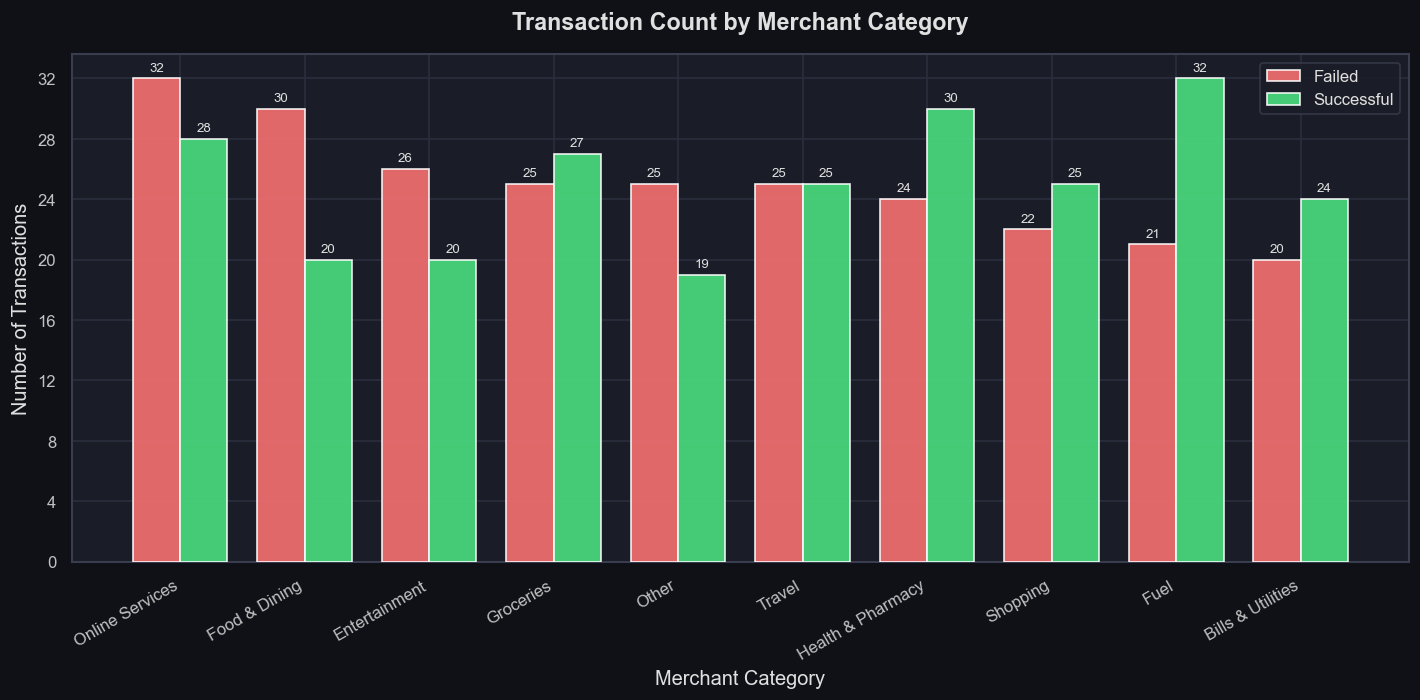

In [41]:
# ── Section B-1: Transaction Count by Merchant Category ─────────────────

cat_status = (
    final_payment_dataset
    .groupby(['merchant_category', 'payment_status'])
    .size()
    .unstack(fill_value=0)
    .sort_values('Failed', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(cat_status))
w = 0.38
bars1 = ax.bar([i - w/2 for i in x], cat_status['Failed'],
               width=w, label='Failed', color=FAIL_COLOR, alpha=0.9, zorder=3)
bars2 = ax.bar([i + w/2 for i in x], cat_status['Successful'],
               width=w, label='Successful', color=SUCCESS_COLOR, alpha=0.9, zorder=3)

ax.set_xticks(list(x))
ax.set_xticklabels(cat_status.index, rotation=30, ha='right')
ax.set_title('Transaction Count by Merchant Category', fontweight='bold', pad=15)
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Number of Transactions')
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Value labels
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('data/processed/chart_category_transactions.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


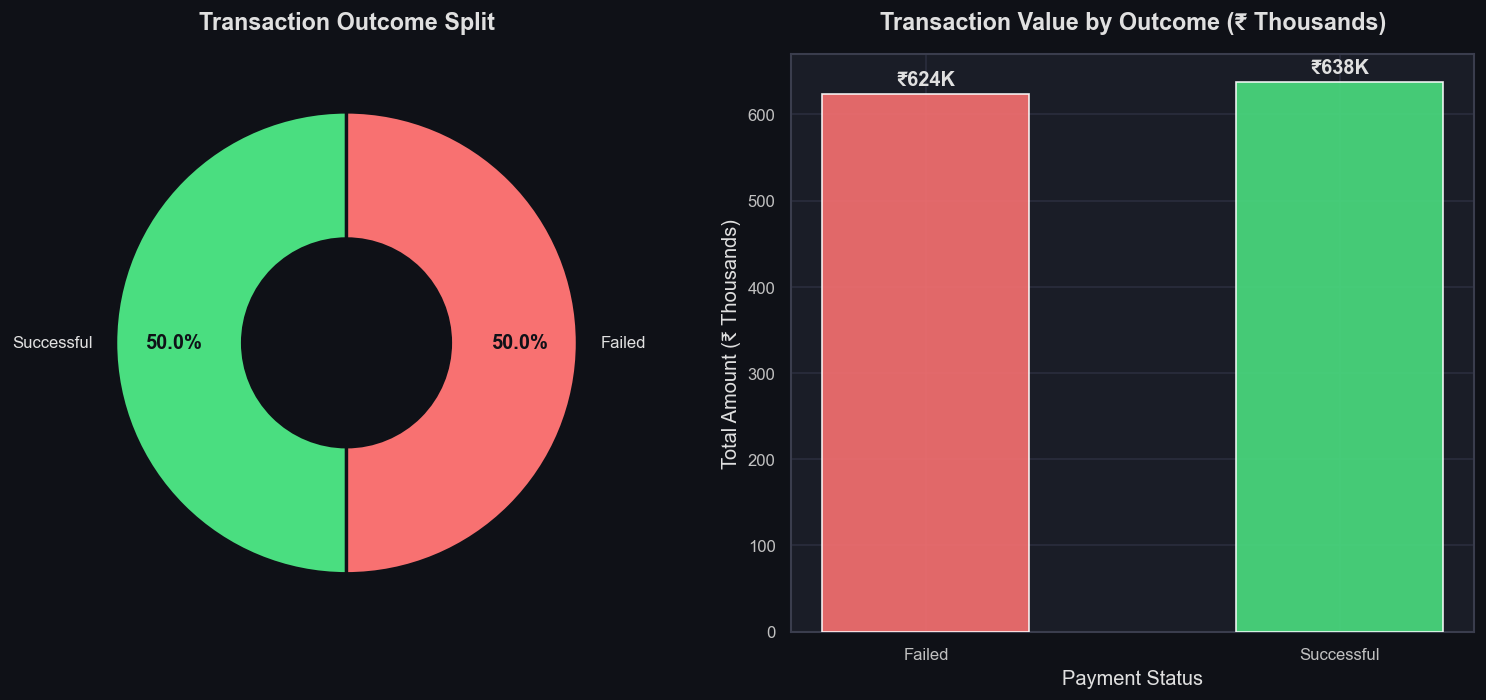

In [42]:
# ── Section B-2: Overall Payment Success vs Failure ──────────────────────

status_counts = final_payment_dataset['payment_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Left: Pie chart ────────────────────────────────────────────────────
ax = axes[0]
wedge_props = dict(width=0.55, edgecolor='#0f1117', linewidth=2)
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=[SUCCESS_COLOR, FAIL_COLOR],
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color('#0f1117')
    at.set_fontweight('bold')
ax.set_title('Transaction Outcome Split', fontweight='bold', pad=15)

# ── Right: Value breakdown bar ─────────────────────────────────────────
ax2 = axes[1]
value_by_status = (
    final_payment_dataset
    .groupby('payment_status')['amount']
    .sum() / 1e3
)  # in thousands
colors = [SUCCESS_COLOR if s == 'Successful' else FAIL_COLOR for s in value_by_status.index]
bars = ax2.bar(value_by_status.index, value_by_status.values, color=colors, alpha=0.9, zorder=3, width=0.5)
for bar, val in zip(bars, value_by_status.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'₹{val:,.0f}K', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Transaction Value by Outcome (₹ Thousands)', fontweight='bold', pad=15)
ax2.set_xlabel('Payment Status')
ax2.set_ylabel('Total Amount (₹ Thousands)')

plt.tight_layout()
plt.savefig('data/processed/chart_overall_outcome.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


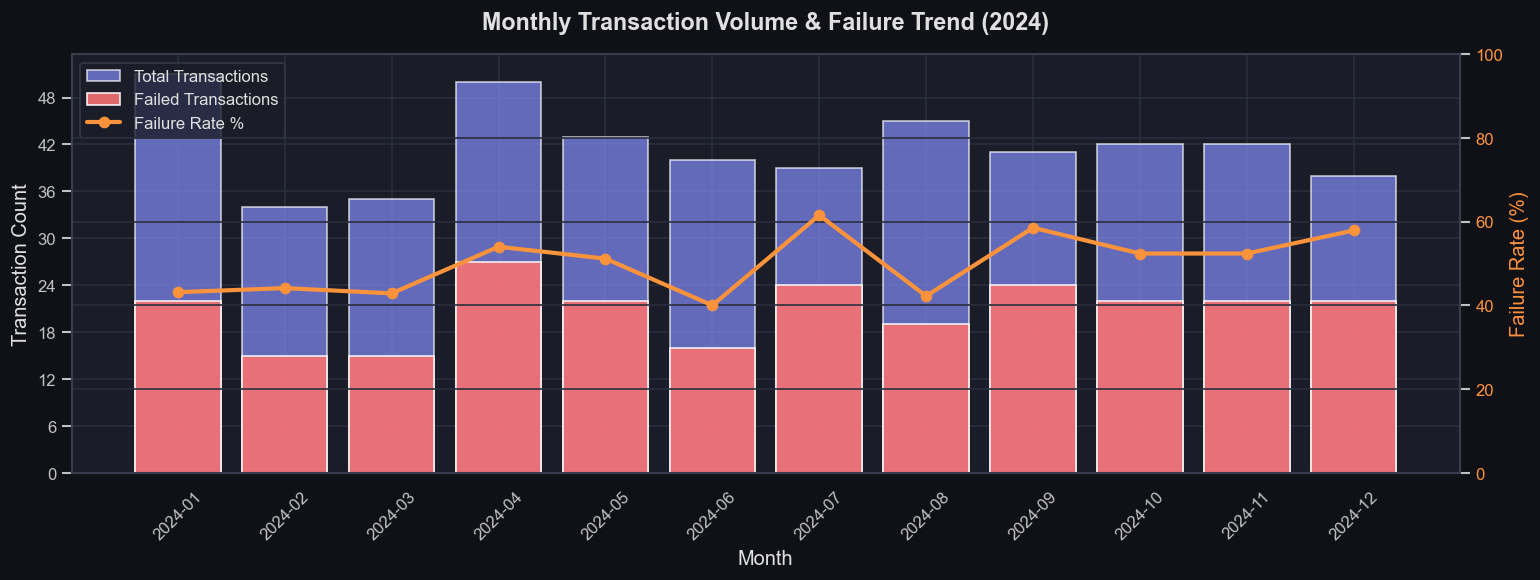

In [43]:
# ── Section C-1: Monthly Transaction Volume & Failure Rate Trend ─────────

import pandas as pd

monthly = final_payment_dataset.copy()
monthly['month'] = pd.to_datetime(monthly['timestamp']).dt.to_period('M')

monthly_agg = (
    monthly
    .groupby('month')
    .agg(
        total=('transaction_id', 'count'),
        failed=('payment_status', lambda x: (x == 'Failed').sum())
    )
    .assign(failure_rate=lambda df: df['failed'] / df['total'] * 100)
)
monthly_agg.index = monthly_agg.index.astype(str)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(monthly_agg.index, monthly_agg['total'], color=PRIMARY_COLOR,
        alpha=0.7, label='Total Transactions', zorder=3)
ax1.bar(monthly_agg.index, monthly_agg['failed'], color=FAIL_COLOR,
        alpha=0.9, label='Failed Transactions', zorder=4)
ax1.set_xlabel('Month')
ax1.set_ylabel('Transaction Count')
ax1.set_title('Monthly Transaction Volume & Failure Trend (2024)', fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.plot(monthly_agg.index, monthly_agg['failure_rate'],
         color=ACCENT_COLOR, marker='o', linewidth=2.5,
         label='Failure Rate %', zorder=5)
ax2.set_ylabel('Failure Rate (%)', color=ACCENT_COLOR)
ax2.tick_params(axis='y', labelcolor=ACCENT_COLOR)
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('data/processed/chart_monthly_trend.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


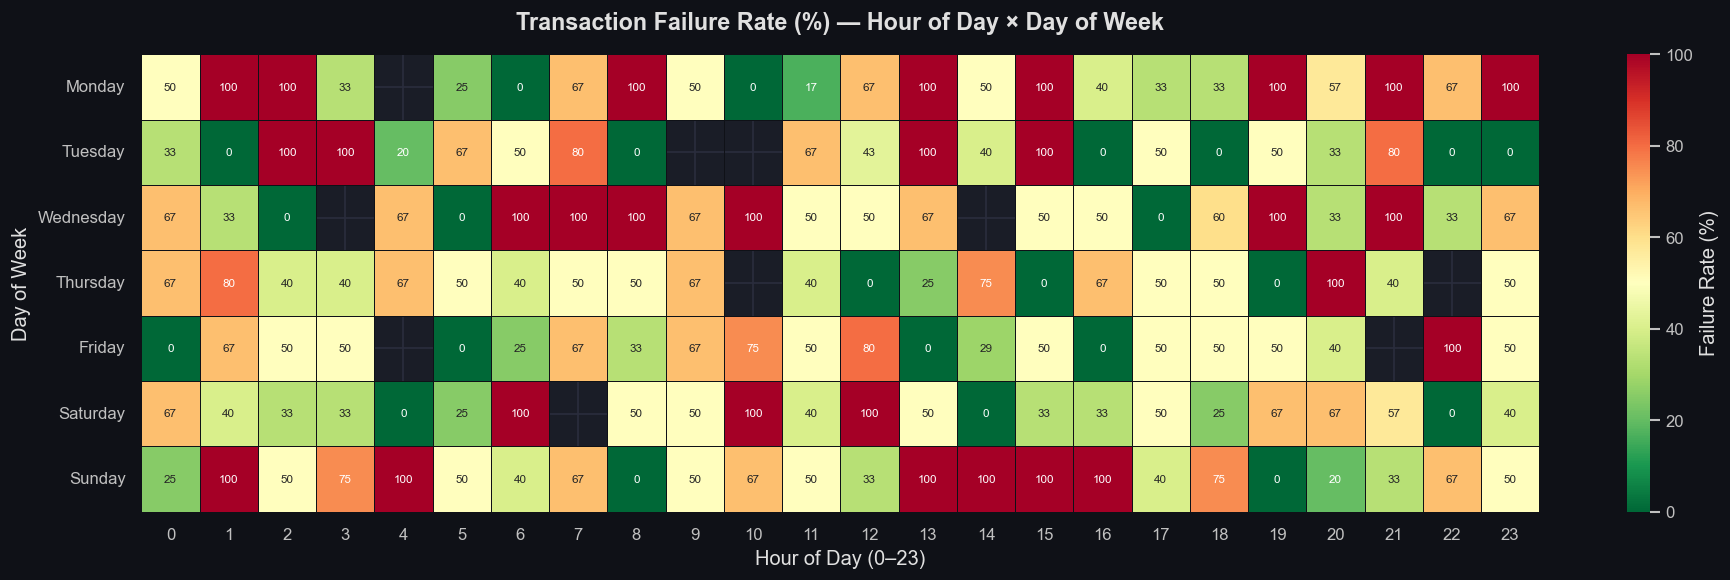

In [44]:
# ── Section C-2: Heatmap — Failure Rate by Hour × Day of Week ────────────

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = (
    final_payment_dataset
    .groupby(['day_of_week', 'transaction_hour'])['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .unstack()
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='#0f1117',
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Failure Rate (%)'},
    annot_kws={'size': 7},
)
ax.set_title('Transaction Failure Rate (%) — Hour of Day × Day of Week',
             fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('data/processed/chart_heatmap_hour_day.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


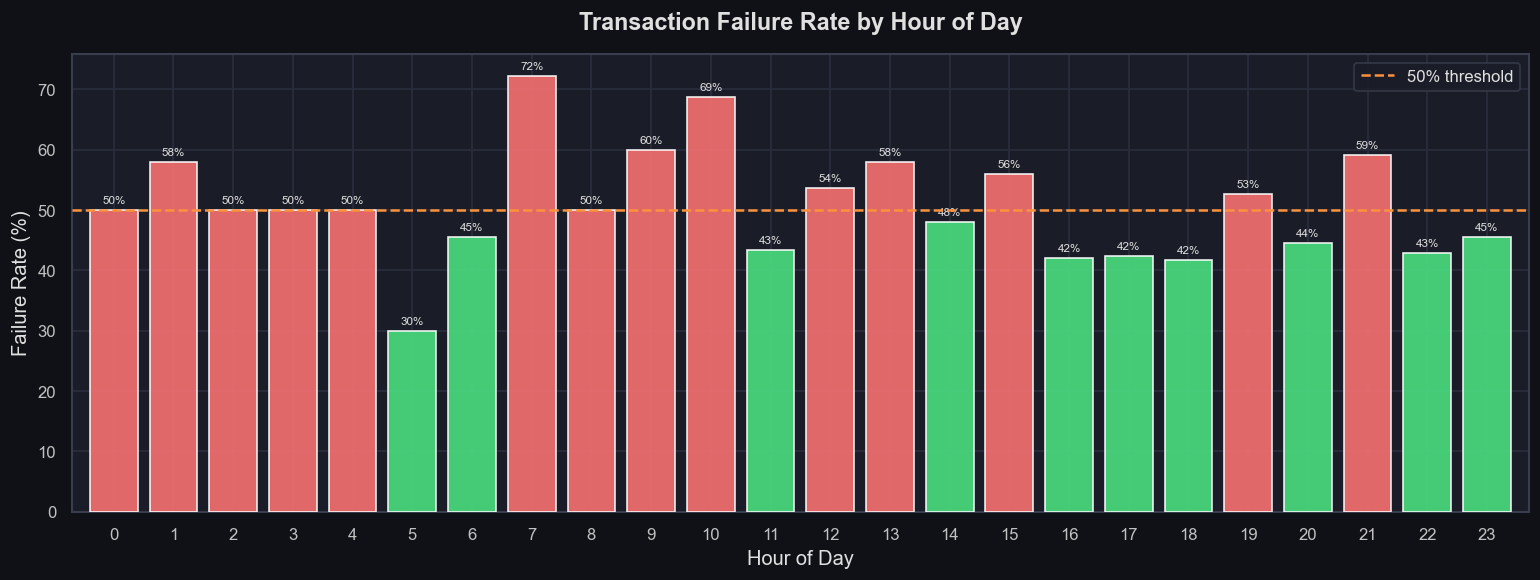

In [45]:
# ── Section C-3: Failure Rate by Hour of Day ─────────────────────────────

hourly_fail = (
    final_payment_dataset
    .groupby('transaction_hour')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .reset_index()
)
hourly_fail.columns = ['hour', 'failure_rate']

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(
    hourly_fail['hour'], hourly_fail['failure_rate'],
    color=[FAIL_COLOR if v >= 50 else SUCCESS_COLOR for v in hourly_fail['failure_rate']],
    alpha=0.9, zorder=3,
)
ax.axhline(50, color=ACCENT_COLOR, linewidth=1.5, linestyle='--', label='50% threshold', zorder=5)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Failure Rate (%)')
ax.set_title('Transaction Failure Rate by Hour of Day', fontweight='bold', pad=15)
ax.set_xticks(range(24))
ax.set_xlim(-0.7, 23.7)
ax.legend()

for bar, v in zip(bars, hourly_fail['failure_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{v:.0f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('data/processed/chart_hourly_failure.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


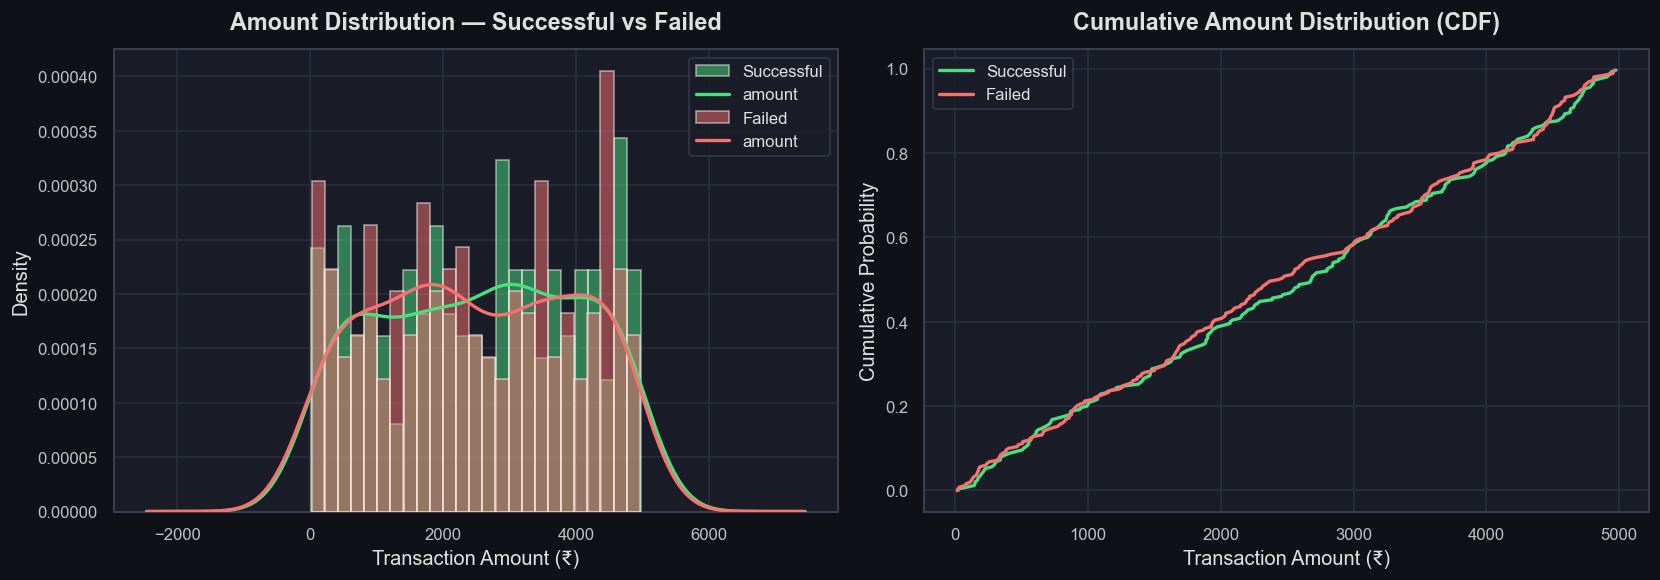

In [46]:
# ── Section D-1: Amount Distribution — Successful vs Failed ──────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram with KDE ─────────────────────────────────────────────────
ax = axes[0]
for status, color, label in [
    ('Successful', SUCCESS_COLOR, 'Successful'),
    ('Failed', FAIL_COLOR, 'Failed'),
]:
    subset = final_payment_dataset[final_payment_dataset['payment_status'] == status]['amount']
    ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True, zorder=3)
    subset.plot.kde(ax=ax, color=color, linewidth=2, zorder=4)

ax.set_title('Amount Distribution — Successful vs Failed', fontweight='bold', pad=12)
ax.set_xlabel('Transaction Amount (₹)')
ax.set_ylabel('Density')
ax.legend()

# ── Cumulative Distribution ─────────────────────────────────────────────
ax2 = axes[1]
for status, color, label in [
    ('Successful', SUCCESS_COLOR, 'Successful'),
    ('Failed', FAIL_COLOR, 'Failed'),
]:
    subset = final_payment_dataset[
        final_payment_dataset['payment_status'] == status
    ]['amount'].sort_values()
    ax2.plot(
        subset.values,
        [i / len(subset) for i in range(len(subset))],
        color=color, linewidth=2, label=label
    )

ax2.set_title('Cumulative Amount Distribution (CDF)', fontweight='bold', pad=12)
ax2.set_xlabel('Transaction Amount (₹)')
ax2.set_ylabel('Cumulative Probability')
ax2.legend()

plt.tight_layout()
plt.savefig('data/processed/chart_amount_distribution.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


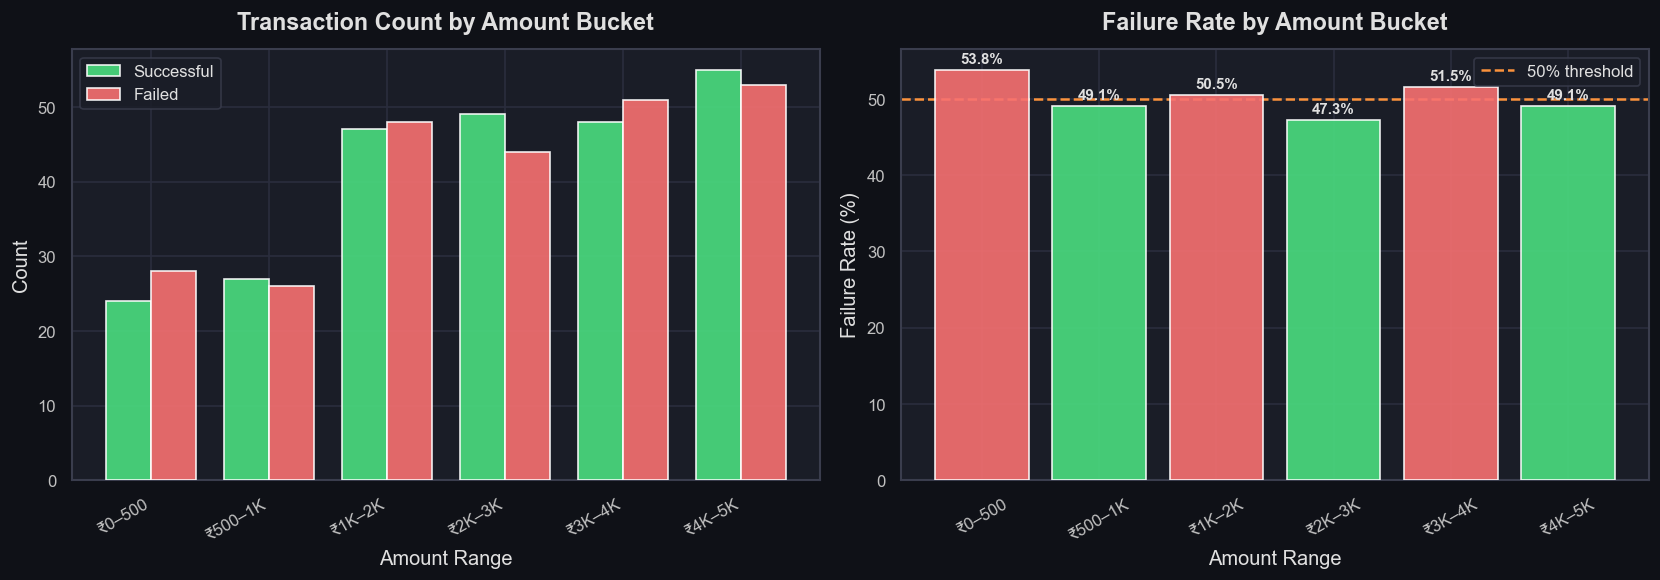


Amount Bucket Summary:
               total  failed  failure_rate
amount_bucket                             
₹0–500            52      28     53.846154
₹500–1K           53      26     49.056604
₹1K–2K            95      48     50.526316
₹2K–3K            93      44     47.311828
₹3K–4K            99      51     51.515152
₹4K–5K           108      53     49.074074


In [47]:
# ── Section D-2: Transaction Amount Segmentation & Failure Rate ───────────

seg_df = final_payment_dataset.copy()
seg_df['amount_bucket'] = pd.cut(
    seg_df['amount'],
    bins=[0, 500, 1000, 2000, 3000, 4000, 5000],
    labels=['₹0–500', '₹500–1K', '₹1K–2K', '₹2K–3K', '₹3K–4K', '₹4K–5K'],
)

bucket_stats = (
    seg_df.groupby('amount_bucket', observed=True)
    .agg(
        total=('transaction_id', 'count'),
        failed=('payment_status', lambda x: (x == 'Failed').sum()),
    )
    .assign(failure_rate=lambda df: df['failed'] / df['total'] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: count by bucket ──────────────────────────────────────────────
ax1 = axes[0]
x = range(len(bucket_stats))
w = 0.38
ax1.bar([i - w/2 for i in x], bucket_stats['total'] - bucket_stats['failed'],
        width=w, label='Successful', color=SUCCESS_COLOR, alpha=0.9, zorder=3)
ax1.bar([i + w/2 for i in x], bucket_stats['failed'],
        width=w, label='Failed', color=FAIL_COLOR, alpha=0.9, zorder=3)
ax1.set_xticks(list(x))
ax1.set_xticklabels(bucket_stats.index, rotation=30, ha='right')
ax1.set_title('Transaction Count by Amount Bucket', fontweight='bold', pad=12)
ax1.set_xlabel('Amount Range')
ax1.set_ylabel('Count')
ax1.legend()

# ── Right: failure rate by bucket ─────────────────────────────────────
ax2 = axes[1]
colors_b = [FAIL_COLOR if v >= 50 else SUCCESS_COLOR for v in bucket_stats['failure_rate']]
bars = ax2.bar(bucket_stats.index, bucket_stats['failure_rate'],
               color=colors_b, alpha=0.9, zorder=3)
ax2.axhline(50, color=ACCENT_COLOR, linewidth=1.5, linestyle='--', label='50% threshold')
for bar, v in zip(bars, bucket_stats['failure_rate']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Failure Rate by Amount Bucket', fontweight='bold', pad=12)
ax2.set_xlabel('Amount Range')
ax2.set_ylabel('Failure Rate (%)')
ax2.legend()
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/processed/chart_amount_segments.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print('\nAmount Bucket Summary:')
print(bucket_stats)


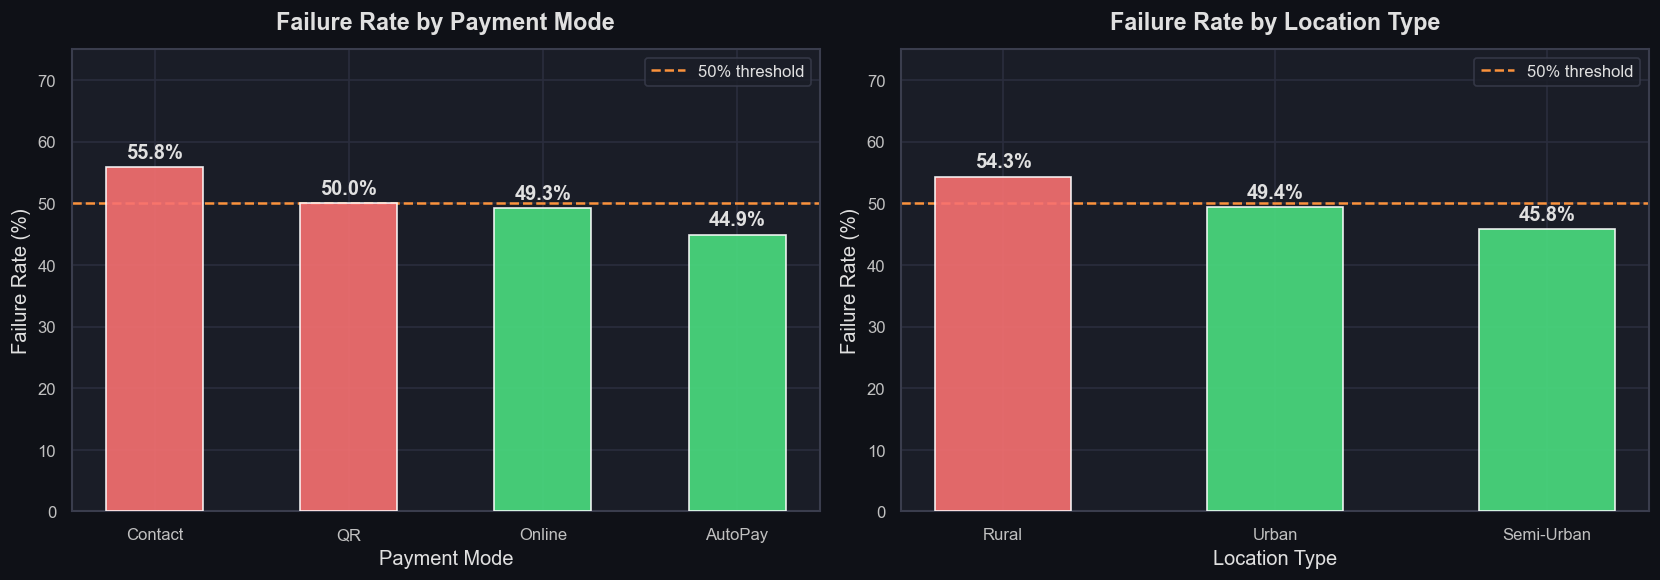

In [48]:
# ── Section E-1: Failure Rate — Payment Mode & Location Type ─────────────

mode_fail = (
    final_payment_dataset
    .groupby('payment_mode')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
)

loc_fail = (
    final_payment_dataset
    .groupby('location_type')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, xlabel in [
    (axes[0], mode_fail, 'Failure Rate by Payment Mode', 'Payment Mode'),
    (axes[1], loc_fail,  'Failure Rate by Location Type', 'Location Type'),
]:
    colors = [FAIL_COLOR if v >= 50 else SUCCESS_COLOR for v in data.values]
    bars = ax.bar(data.index, data.values, color=colors, alpha=0.9, zorder=3, width=0.5)
    ax.axhline(50, color=ACCENT_COLOR, linewidth=1.5, linestyle='--', label='50% threshold')
    ax.set_title(title, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Failure Rate (%)')
    ax.set_ylim(0, 75)
    ax.legend()
    for bar, v in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/chart_mode_location_failure.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


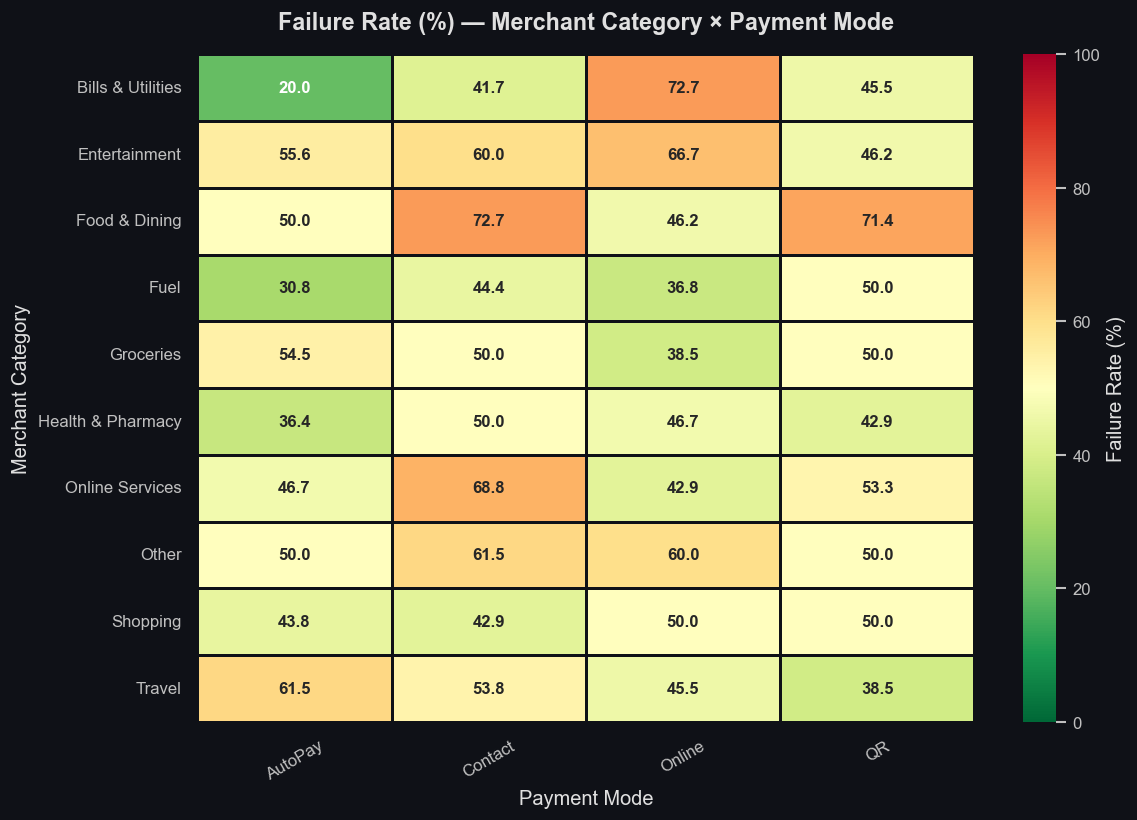

In [49]:
# ── Section E-2: Failure Rate Heatmap — Category × Payment Mode ──────────

heat_pivot = (
    final_payment_dataset
    .groupby(['merchant_category', 'payment_mode'])['payment_status']
    .apply(lambda x: round((x == 'Failed').sum() / len(x) * 100, 1))
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heat_pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.8,
    linecolor='#0f1117',
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Failure Rate (%)'},
    annot_kws={'size': 10, 'weight': 'bold'},
)
ax.set_title('Failure Rate (%) — Merchant Category × Payment Mode',
             fontweight='bold', pad=15)
ax.set_xlabel('Payment Mode')
ax.set_ylabel('Merchant Category')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/processed/chart_heatmap_category_mode.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


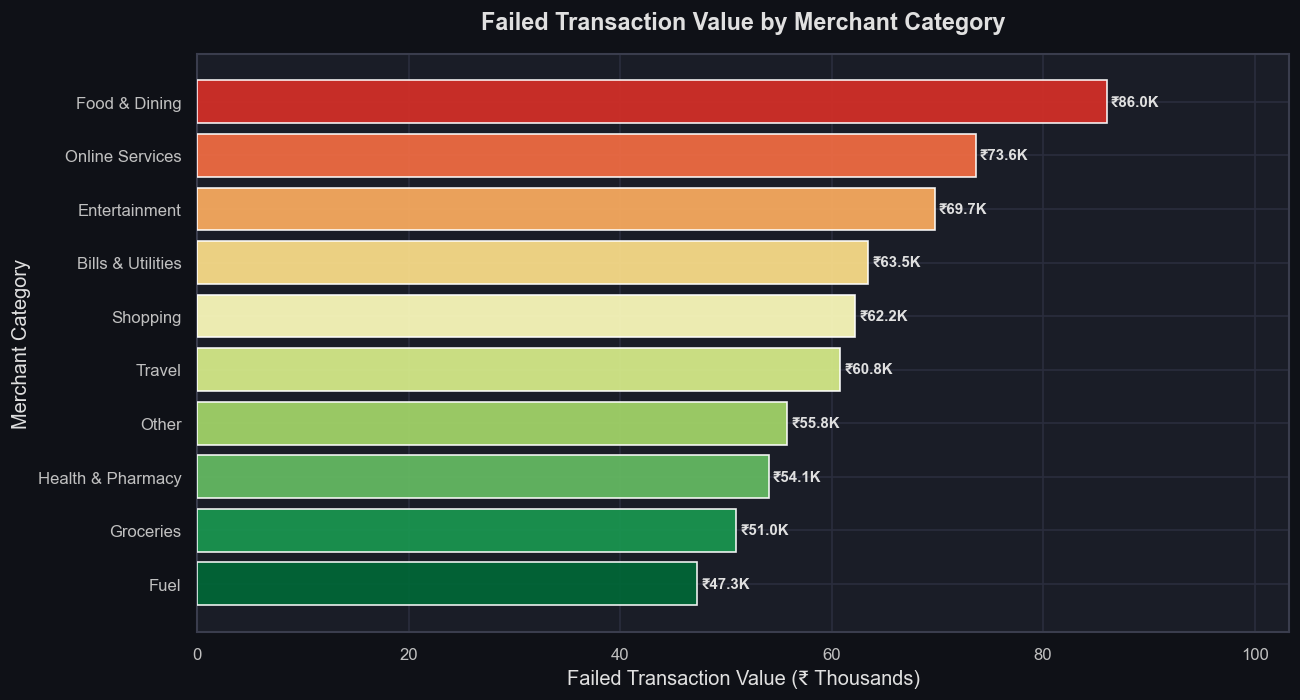

In [50]:
# ── Section F-1: Failed Transaction Value by Merchant Category ────────────

rev_cat = (
    final_payment_dataset[final_payment_dataset['payment_status'] == 'Failed']
    .groupby('merchant_category')['amount']
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6))

gradient_colors = plt.cm.RdYlGn_r(
    [i / len(rev_cat) for i in range(len(rev_cat))]
)

bars = ax.barh(rev_cat.index, rev_cat.values / 1e3,
               color=gradient_colors, alpha=0.92, zorder=3)

for bar, v in zip(bars, rev_cat.values / 1e3):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'₹{v:,.1f}K', va='center', fontsize=9, fontweight='bold')

ax.set_title('Failed Transaction Value by Merchant Category',
             fontweight='bold', pad=15)
ax.set_xlabel('Failed Transaction Value (₹ Thousands)')
ax.set_ylabel('Merchant Category')
ax.set_xlim(0, rev_cat.max() / 1e3 * 1.2)

plt.tight_layout()
plt.savefig('data/processed/chart_failed_value_category.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


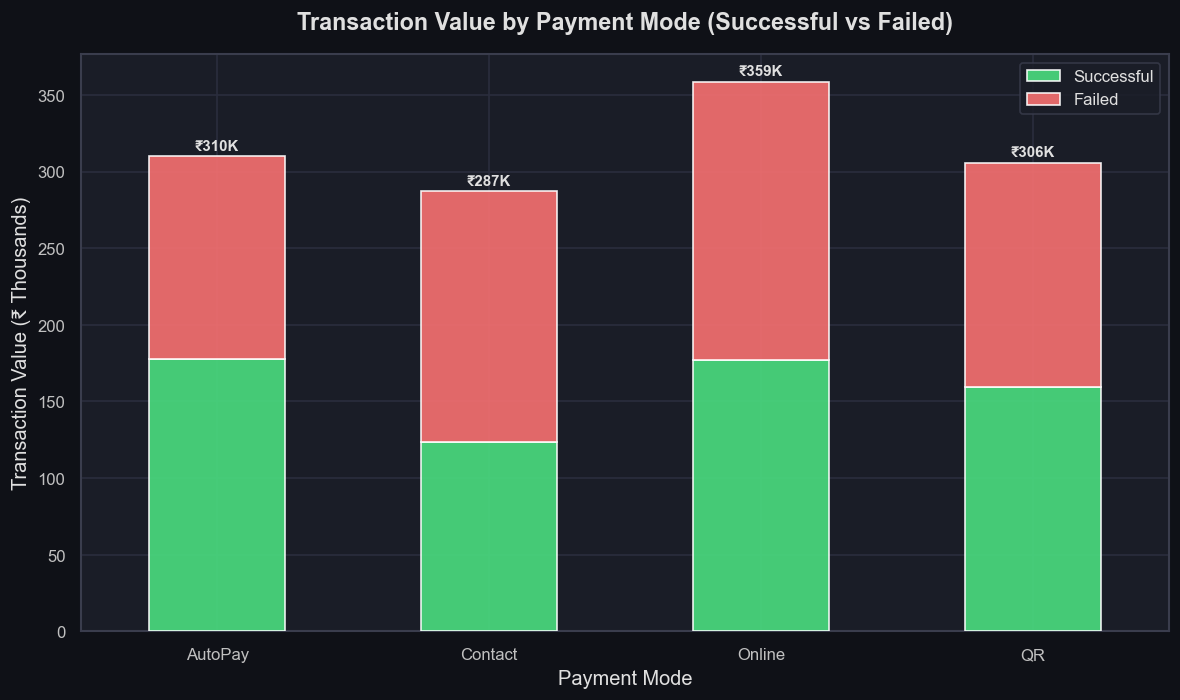

In [51]:
# ── Section F-2: Successful vs Failed Transaction Value by Payment Mode ───

mode_val = (
    final_payment_dataset
    .groupby(['payment_mode', 'payment_status'])['amount']
    .sum()
    .unstack(fill_value=0)
    / 1e3
)

fig, ax = plt.subplots(figsize=(10, 6))

mode_val['Successful'].plot(kind='bar', ax=ax, color=SUCCESS_COLOR,
                             alpha=0.9, label='Successful', zorder=3)
mode_val['Failed'].plot(kind='bar', ax=ax, color=FAIL_COLOR,
                         alpha=0.9, label='Failed',
                         bottom=mode_val['Successful'], zorder=3)

for i, (mode, row) in enumerate(mode_val.iterrows()):
    total = row['Successful'] + row['Failed']
    ax.text(i, total + 2, f'₹{total:,.0f}K',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title('Transaction Value by Payment Mode (Successful vs Failed)',
             fontweight='bold', pad=15)
ax.set_xlabel('Payment Mode')
ax.set_ylabel('Transaction Value (₹ Thousands)')
ax.tick_params(axis='x', rotation=0)
ax.legend()

plt.tight_layout()
plt.savefig('data/processed/chart_stacked_mode_value.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


---

## 📋 Data Analytics Summary — Key Findings

### 🔢 Overall KPIs
| Metric | Value |
|---|---|
| Total Transactions | 500 |
| Overall Failure Rate | **50.0%** |
| Total Transaction Value | ₹12,61,834 |
| Failed Transaction Value | **₹6,24,003 (49.45%)** |

---

### 📦 Merchant Category Insights
- **Highest failure rate**: Food & Dining (60%) and Entertainment (56.5%)
- **Lowest failure rate**: Fuel (39.6%) and Health & Pharmacy (44.4%)
- **Highest failed value**: Food & Dining (₹86K), Online Services (₹73.6K)

### 💳 Payment Mode Insights
- **Contact payments** have the highest failure rate at **55.8%** — most at-risk mode
- **AutoPay** is the most reliable with **44.9%** failure rate
- **Online** mode carries the highest failed transaction value (₹1,81,718)

### 🌍 Location Insights
- **Rural areas** suffer the highest failure rate (**54.3%**) and highest failed value (₹2,40,184)
- **Semi-Urban** areas are most reliable (45.8% failure rate)

### ⏰ Time-based Insights
- **Hour 7 (7AM)** and **Hour 10 (10AM)** have the highest failure rates (72% and 69%)
- **Hour 5 (5AM)** is the safest hour — only **30%** failure rate
- **Wednesday** and **Sunday** have the highest weekly failure rates (~58% and 56%)

### 💡 Recommendations
1. **Prioritize reliability improvements** for Contact payment mode in Rural areas
2. **Investigate Food & Dining and Entertainment** category failures — potential UPI timeout or bank issues
3. **Deploy retry logic** specifically during 7–10 AM window on Wednesdays
4. **₹6.24 lakh** in failed transaction value is a direct revenue recovery opportunity


In [52]:
# ── Section G-2: Final Analytics Summary Print ────────────────────────────

print('=' * 60)
print('  UPI TRANSACTION DATA ANALYTICS — FINAL SUMMARY')
print('=' * 60)

total      = len(final_payment_dataset)
failed     = (final_payment_dataset['payment_status'] == 'Failed').sum()
successful = total - failed
fail_rate  = failed / total * 100
total_val  = final_payment_dataset['amount'].sum()
fail_val   = final_payment_dataset.loc[
    final_payment_dataset['payment_status'] == 'Failed', 'amount'
].sum()
fail_val_pct = fail_val / total_val * 100

print(f'\n📊 OVERALL')
print(f'  Total Transactions   : {total:,}')
print(f'  Successful           : {successful:,} ({100-fail_rate:.1f}%)')
print(f'  Failed               : {failed:,} ({fail_rate:.1f}%)')
print(f'  Total Value          : ₹{total_val:,.2f}')
print(f'  Failed Value         : ₹{fail_val:,.2f} ({fail_val_pct:.1f}%)')

print(f'\n💳 BY PAYMENT MODE (Failure Rate)')
for mode, rate in (
    final_payment_dataset.groupby('payment_mode')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
).items():
    print(f'  {mode:<12}: {rate:.1f}%')

print(f'\n🌍 BY LOCATION (Failure Rate)')
for loc, rate in (
    final_payment_dataset.groupby('location_type')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
).items():
    print(f'  {loc:<12}: {rate:.1f}%')

print(f'\n📦 TOP 3 HIGH-RISK CATEGORIES')
top3 = (
    final_payment_dataset.groupby('merchant_category')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
    .head(3)
)
for cat, rate in top3.items():
    print(f'  {cat:<22}: {rate:.1f}%')

print(f'\n⏰ PEAK FAILURE HOURS')
peak_hours = (
    final_payment_dataset.groupby('transaction_hour')['payment_status']
    .apply(lambda x: (x == 'Failed').sum() / len(x) * 100)
    .sort_values(ascending=False)
    .head(3)
)
for hr, rate in peak_hours.items():
    print(f'  Hour {hr:02d}:00   : {rate:.1f}% failure rate')

print(f'\n✅ Datasets saved in notebook/data/processed/')
print('   • final_payment_dataset.csv')
print('   • retry_dataset.csv')
print('   • response_code_dataset.csv')
print(f'\n📈 Charts saved in notebook/data/processed/')
print('   • chart_category_transactions.png')
print('   • chart_overall_outcome.png')
print('   • chart_monthly_trend.png')
print('   • chart_heatmap_hour_day.png')
print('   • chart_hourly_failure.png')
print('   • chart_amount_distribution.png')
print('   • chart_amount_segments.png')
print('   • chart_mode_location_failure.png')
print('   • chart_heatmap_category_mode.png')
print('   • chart_failed_value_category.png')
print('   • chart_stacked_mode_value.png')
print('=' * 60)


  UPI TRANSACTION DATA ANALYTICS — FINAL SUMMARY

📊 OVERALL
  Total Transactions   : 500
  Successful           : 250 (50.0%)
  Failed               : 250 (50.0%)
  Total Value          : ₹1,261,834.27
  Failed Value         : ₹624,002.79 (49.5%)

💳 BY PAYMENT MODE (Failure Rate)
  Contact     : 55.8%
  QR          : 50.0%
  Online      : 49.3%
  AutoPay     : 44.9%

🌍 BY LOCATION (Failure Rate)
  Rural       : 54.3%
  Urban       : 49.4%
  Semi-Urban  : 45.8%

📦 TOP 3 HIGH-RISK CATEGORIES
  Food & Dining         : 60.0%
  Other                 : 56.8%
  Entertainment         : 56.5%

⏰ PEAK FAILURE HOURS
  Hour 07:00   : 72.2% failure rate
  Hour 10:00   : 68.8% failure rate
  Hour 09:00   : 60.0% failure rate

✅ Datasets saved in notebook/data/processed/
   • final_payment_dataset.csv
   • retry_dataset.csv
   • response_code_dataset.csv

📈 Charts saved in notebook/data/processed/
   • chart_category_transactions.png
   • chart_overall_outcome.png
   • chart_monthly_trend.png
   • ch